# 📓 Linear Regression from Scratch

### 🎯 Objective
- Implement a linear regression model using gradient descent.
- Derive the gradient updates, write a scikit-learn-like class, and evaluate using synthetic data.
- Compare the result of the same with library code output
- Use R2-Score and Mean Absolute Percentage error as Performance metric on test data

## 📊 Generate Synthetic Data

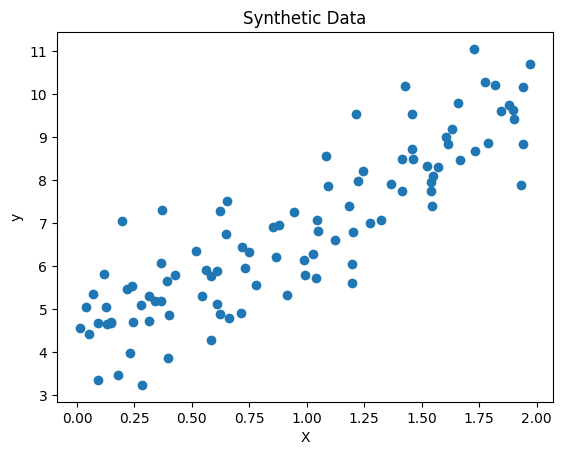

In [54]:

import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Plot
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()


## Do Train-Test Split (75%-25%)

In [55]:
# Write your code here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


## Do the Linear Regression with Scikit-Learn Library

In [56]:
from numpy.random import RandomState
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Create a Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test se
y_pred_sklearn = linear_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred_sklearn)
mape = mean_absolute_percentage_error(y_test, y_pred_sklearn)

print(f"Scikit-learn Linear Regression R2 Score: {r2:.4f}")
print(f"Scikit-learn Linear Regression MAPE: {mape:.4f}")

Scikit-learn Linear Regression R2 Score: 0.8311
Scikit-learn Linear Regression MAPE: 0.0848


## Do Ridge and Lasso Regression and Compare the evaluation metrics in a table

In [57]:
from sklearn.linear_model import Ridge
import pandas as pd
lr_model=Ridge()
lr_model.fit(X_train,y_train)
y_pred_ridge=lr_model.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)

print(f"Scikit-learn Ridge Regression R2 Score: {r2_ridge:.4f}")
print(f"Scikit-learn Ridge Regression MAPE: {mape_ridge:.4f}")

Scikit-learn Ridge Regression R2 Score: 0.8260
Scikit-learn Ridge Regression MAPE: 0.0824


In [58]:
from sklearn.linear_model import Lasso
lr_model=Lasso()
lr_model.fit(X_train,y_train)
y_pred_lasso=lr_model.predict(X_test)
r2_lasso=r2_score(y_test,y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)

print(f"Scikit-learn Lasso Regression R2 Score: {r2_lasso:.4f}")
print(f"Scikit-learn Lasso Regression MAPE: {mape_lasso:.4f}")

Scikit-learn Lasso Regression R2 Score: -0.0853
Scikit-learn Lasso Regression MAPE: 0.2424


In [59]:
import pandas as pd

# Create a dictionary with the results
results = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2 Score': [r2, r2_ridge, r2_lasso],
    'MAPE': [mape, mape_ridge, mape_lasso]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(results)

# Display the DataFrame
display(results_df.round(4))

,Model,R2 Score,MAPE
0,Linear Regression,0.8311,0.0848
1,Ridge Regression,0.8260,0.0824
2,Lasso Regression,-0.0853,0.2424


## Custom Implementation

## 🧮 Derive the Gradient Updates
Use the chain rule to derive the gradients of the loss function (Mean Square Error):

$$ \text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2 $$

Derive:
- ∂Loss/∂m
- ∂Loss/∂c

Write the derivation here/add screenshot of your derivation here:
### Mean Squared Error Loss

Loss:

$$
\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2
$$

---

### Define prediction

$$
\hat{y}_i = mx_i + c
$$

$$
e_i = y_i - \hat{y}_i
$$

$$
\text{Loss} = \frac{1}{N}\sum_{i=1}^{N} e_i^2
$$

---

# Gradient w.r.t m

Chain rule:

$$
\frac{\partial \text{Loss}}{\partial m}
=
\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial (e_i^2)}{\partial m}
$$

$$
\frac{\partial (e_i^2)}{\partial m}
=
2 e_i \cdot \frac{\partial e_i}{\partial m}
$$

Since

$$
e_i = y_i - (mx_i + c)
$$

$$
\frac{\partial e_i}{\partial m} = -x_i
$$

Therefore

$$
\frac{\partial \text{Loss}}{\partial m}
=
-\frac{2}{N}\sum_{i=1}^{N}
x_i (y_i - (mx_i + c))
$$

---

# Gradient w.r.t c

$$
\frac{\partial \text{Loss}}{\partial c}
=
\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial (e_i^2)}{\partial c}
$$

$$
\frac{\partial (e_i^2)}{\partial c}
=
2 e_i \cdot (-1)
$$

Therefore

$$
\frac{\partial \text{Loss}}{\partial c}
=
-\frac{2}{N}\sum_{i=1}^{N}
(y_i - (mx_i + c))
$$

## 🧠 Custom Linear Regression Class

In [60]:
import numpy as np

class MyLinearRegression:
    def __init__(self):
        self.m = None  # slope
        self.c = None  # intercept
        self.loss_history = []

    def fit(self, X, y, lr=0.01, n_iters=1000):
        # Initialize coefficients randomly or with zeros
        # X needs to be 2D array, y needs to be 2D array
        X_flat = X.flatten()
        y_flat = y.flatten()

        if self.m is None:
            self.m = np.random.randn()
        if self.c is None:
            self.c = np.random.randn()

        N = len(X_flat)

        for _ in range(n_iters):
            # Predictions
            y_pred = self.m * X_flat + self.c

            # Calculate Loss (Mean Squared Error)
            loss = np.mean((y_flat - y_pred)**2)
            self.loss_history.append(loss)

            # Calculate Gradients
            # ∂Loss/∂m = -2/N * sum(X * (y - y_pred))
            # ∂Loss/∂c = -2/N * sum(y - y_pred)
            dm = (-2/N) * np.sum(X_flat * (y_flat - y_pred))
            dc = (-2/N) * np.sum(y_flat - y_pred)

            # Update coefficients
            self.m = self.m - lr * dm
            self.c = self.c - lr * dc

        self.coef_ = np.array([self.m, self.c]) # Store coefficients similar to sklearn

    def predict(self, X):
        if self.m is None or self.c is None:
            raise Exception("Model has not been trained yet. Call fit() first.")
        return self.m * X + self.c

    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
        self.fit(X, y, lr, n_iters)
        return self.predict(X)

## 🔁 Train the Model and Visualize the Fit

## 📉 Plot the Loss Curve

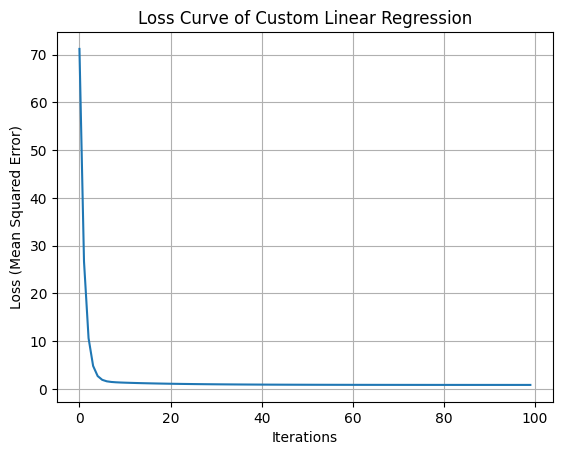

In [61]:
import matplotlib.pyplot as plt

# Plot the loss history
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Loss Curve of Custom Linear Regression")
plt.grid(True)
plt.show()

## 🌟 Bonus Task: Stochastic Gradient Descent
Implement a class `MyLinearRegressionSGD` that uses one training sample per iteration to update weights.

In [62]:
import numpy as np

class MyLinearRegressionSGD:
    def __init__(self):
        self.m = None  # slope
        self.c = None  # intercept
        self.loss_history = []

    def fit(self, X, y, lr=0.01, n_iters=1000):
        # X needs to be 2D array, y needs to be 2D array
        X_flat = X.flatten()
        y_flat = y.flatten()

        if self.m is None:
            self.m = np.random.randn()
        if self.c is None:
            self.c = np.random.randn()

        N = len(X_flat) # Number of training samples

        for i in range(n_iters):
            # Select a random sample for SGD
            rand_idx = np.random.randint(0, N)
            X_sample = X_flat[rand_idx]
            y_sample = y_flat[rand_idx]

            # Prediction for the single sample
            y_pred_sample = self.m * X_sample + self.c

            # Calculate Loss (Mean Squared Error) for the single sample
            # Note: For SGD, loss is often calculated over a small batch or single sample
            # Here, we will record the loss over the entire dataset periodically
            # or just for the sample for simplicity. Let's record full loss for comparison.
            y_pred_full = self.m * X_flat + self.c
            loss = np.mean((y_flat - y_pred_full)**2)
            self.loss_history.append(loss)

            # Calculate Gradients for the single sample
            # ∂Loss/∂m = -2 * X_sample * (y_sample - y_pred_sample)
            # ∂Loss/∂c = -2 * (y_sample - y_pred_sample)
            dm = -2 * X_sample * (y_sample - y_pred_sample)
            dc = -2 * (y_sample - y_pred_sample)

            # Update coefficients
            self.m = self.m - lr * dm
            self.c = self.c - lr * dc

        self.coef_ = np.array([self.m, self.c]) # Store coefficients similar to sklearn

    def predict(self, X):
        if self.m is None or self.c is None:
            raise Exception("Model has not been trained yet. Call fit() first.")
        return self.m * X + self.c

    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
        self.fit(X, y, lr, n_iters)
        return self.predict(X)

In [63]:
# Plot loss curve while using Stochastic Gradient Descent

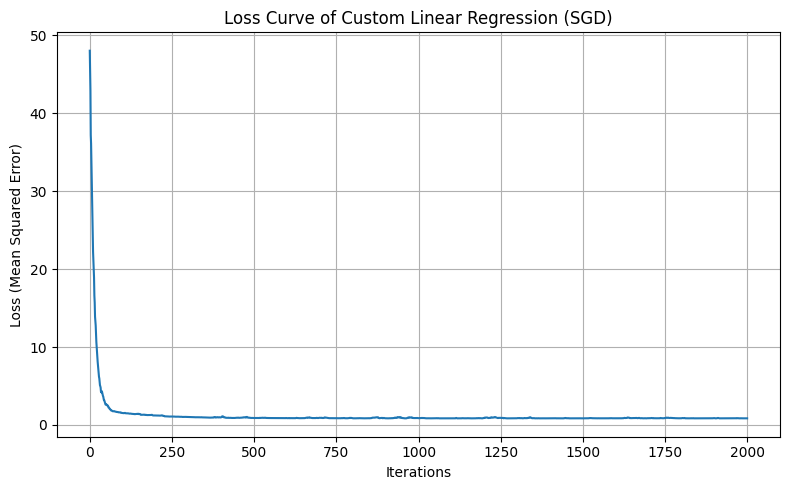

Learned coefficients (m, c) for SGD model: [2.69642499 4.25526427]


In [64]:
import matplotlib.pyplot as plt

# Instantiate and train the SGD model
sgd_model = MyLinearRegressionSGD()
sgd_model.fit(X_train, y_train, lr=0.01, n_iters=2000)

# Plot the loss history
plt.figure(figsize=(8, 5))
plt.plot(sgd_model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Loss Curve of Custom Linear Regression (SGD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print coefficients
print("Learned coefficients (m, c) for SGD model:", sgd_model.coef_)

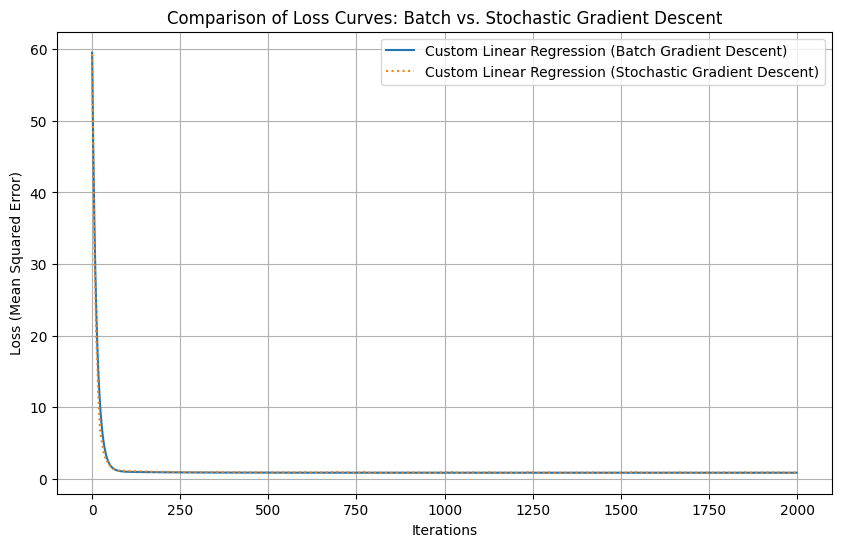

Final Loss (Batch GD): 0.8510
Final Loss (SGD): 0.8540


In [65]:
import matplotlib.pyplot as plt

# Instantiate and train the MyLinearRegression model (if not already trained in this session)
batch_model = MyLinearRegression()
batch_model.fit(X_train, y_train, lr=0.01, n_iters=2000) # Using more iterations for comparison

# Instantiate and train the MyLinearRegressionSGD model (if not already trained in this session)
sgd_model = MyLinearRegressionSGD()
sgd_model.fit(X_train, y_train, lr=0.01, n_iters=2000) # Using same iterations for comparison

plt.figure(figsize=(10, 6))
plt.plot(batch_model.loss_history, label='Custom Linear Regression (Batch Gradient Descent)')
plt.plot(sgd_model.loss_history, label='Custom Linear Regression (Stochastic Gradient Descent)',linestyle="dotted")
plt.xlabel('Iterations')
plt.ylabel('Loss (Mean Squared Error)')
plt.title('Comparison of Loss Curves: Batch vs. Stochastic Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Loss (Batch GD): {batch_model.loss_history[-1]:.4f}")
print(f"Final Loss (SGD): {sgd_model.loss_history[-1]:.4f}")

## Visualize the prediction result of Library version and Custom regression code created

In [66]:
# Write your code here

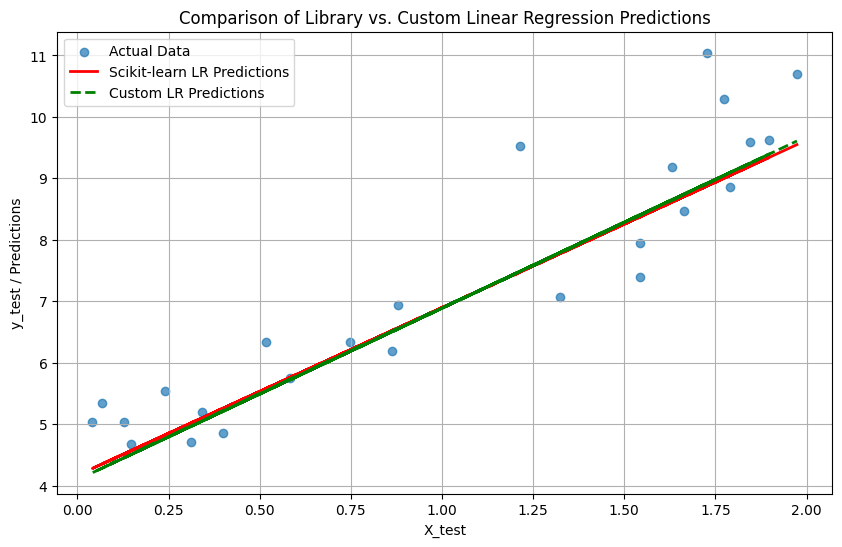

In [67]:
import matplotlib.pyplot as plt

# Plot the original data
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Actual Data', alpha=0.7)

# Plot Scikit-learn Linear Regression predictions
# Ensure X_test and y_pred_sklearn are flattened for plotting if they are 2D arrays
plt.plot(X_test.flatten(), y_pred_sklearn.flatten(), color='red', linestyle='-', linewidth=2, label='Scikit-learn LR Predictions')

# Plot Custom Linear Regression predictions
# Ensure X_test and y_pred are flattened for plotting if they are 2D arrays
plt.plot(X_test.flatten(), y_pred.flatten(), color='green', linestyle='--', linewidth=2, label='Custom LR Predictions')

plt.xlabel('X_test')
plt.ylabel('y_test / Predictions')
plt.title('Comparison of Library vs. Custom Linear Regression Predictions')
plt.legend()
plt.grid(True)
plt.show()

## ✅ Checklist
- [ ] Did linear regression using scikit-learn API
- [ ] Did Ridge and Lasso regression and compiled the result (R2 and MAPE) as a table
- [ ] Derived gradients using chain rule
- [ ] Implemented custom Linear Regression class
- [ ] Trained using gradient descent
- [ ] Visualized predictions and loss
- [ ] Implemented stochastic gradient descent (bonus)
- [ ] Visualized predictions and loss for stochastic gradient descent (bonus)
- [ ] Visualize the prediction result of Library version and custom version